# K Optimization

In [1]:
# Imports

import os
import sys

sys.path.append(os.path.abspath("../src"))
sys.path.append(os.path.abspath(".."))

import pandas as pd
from preprocessing import get_proccesed_X
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

In [2]:
# Data Load

df = pd.read_csv(r"../dataset/Wholesale customers data.csv")

X = get_proccesed_X(df)

X

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347
...,...,...,...,...,...,...
435,1.401312,0.848446,0.850760,2.075222,-0.566831,0.241091
436,2.155293,-0.592142,-0.757165,0.296561,-0.585519,0.291501
437,0.200326,1.314671,2.348386,-0.543380,2.511218,0.121456
438,-0.135384,-0.517536,-0.602514,-0.419441,-0.569770,0.213046


In [3]:
# Calculating WCSS

wcss = []

score = []

for k in range(2 , 11) :
    model = KMeans(
        n_clusters = k ,
        n_init = 10 ,
        random_state = 42
    )

    model.fit(X)

    label = model.labels_

    wcss.append(model.inertia_)

    score.append(silhouette_score(X , label))

    

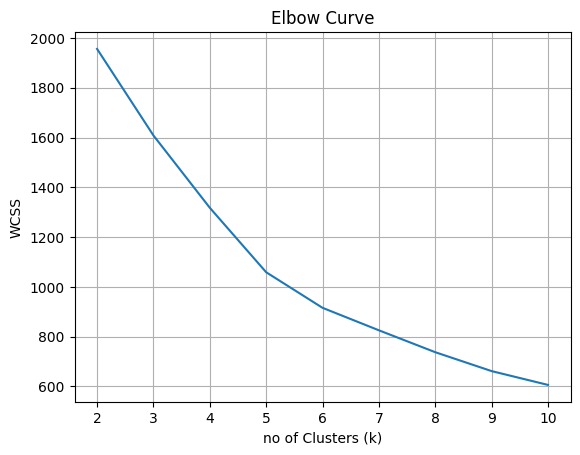

In [4]:
# Elbow Method

plt.plot( range(2 , 11) , wcss)

plt.xlabel("no of Clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Curve")
plt.grid()
plt.show()

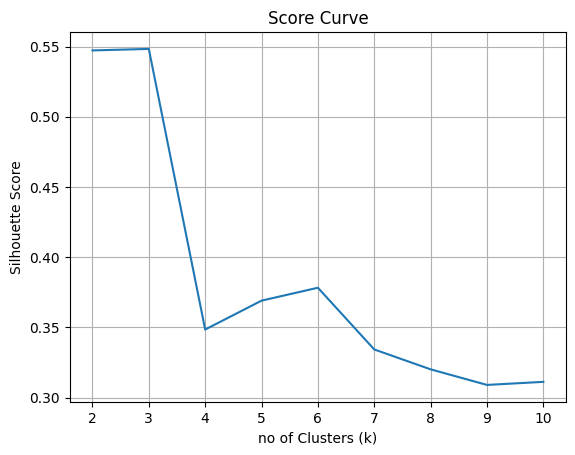

In [5]:
# Silhouette Score PLot

plt.plot( range(2 , 11) , score)

plt.xlabel("no of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Score Curve")
plt.grid()
plt.show()

# "The elbow point occurred around k=5–6. Although silhouette score was highest at k=2–3, those clusters were too broad for meaningful customer segmentation. k=6 provided better business interpretability and more actionable customer groups."